In [25]:
import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

Notebook last run (end-to-end): 2026-02-02 12:07:48.992039


# imports

In [26]:
import os
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation, Dropout, BatchNormalization
from tensorflow.keras import Sequential

# open data sets

In [27]:
import kagglehub

# Download latest version
initial_download_path = kagglehub.dataset_download("asfarhossainsitab/coral-reefs-images")

print("Path to dataset files:", initial_download_path)

Using Colab cache for faster access to the 'coral-reefs-images' dataset.
Path to dataset files: /kaggle/input/coral-reefs-images


In [28]:
for dirpath, dirnames, filenames in os.walk(f"{initial_download_path}/Coral Reef Images"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 3 directories and 0 images in '/kaggle/input/coral-reefs-images/Coral Reef Images'.
There are 2 directories and 0 images in '/kaggle/input/coral-reefs-images/Coral Reef Images/valid'.
There are 0 directories and 240 images in '/kaggle/input/coral-reefs-images/Coral Reef Images/valid/Bleached'.
There are 0 directories and 223 images in '/kaggle/input/coral-reefs-images/Coral Reef Images/valid/Healthy'.
There are 2 directories and 0 images in '/kaggle/input/coral-reefs-images/Coral Reef Images/test'.
There are 0 directories and 135 images in '/kaggle/input/coral-reefs-images/Coral Reef Images/test/Bleached'.
There are 0 directories and 122 images in '/kaggle/input/coral-reefs-images/Coral Reef Images/test/Healthy'.
There are 2 directories and 0 images in '/kaggle/input/coral-reefs-images/Coral Reef Images/train'.
There are 0 directories and 4980 images in '/kaggle/input/coral-reefs-images/Coral Reef Images/train/Bleached'.
There are 0 directories and 4682 images in '/kaggle/inp

In [29]:
# variables
path = f"{initial_download_path}/Coral Reef Images"
train_dir = f'{path}/train'
valid_dir = f'{path}/valid'
test_dir = f'{path}/test'
train_dir_Healthy = f'{path}/train/Healthy'
train_dir_Bleached = f'{path}/train/Bleached'
valid_dir_Healthy = f'{path}/valid/Healthy'
valid_dir_Bleached = f'{path}/valid/Bleached'
test_dir_Healthy = f'{path}/test/Healthy'
test_dir_Bleached = f'{path}/test/Bleached'

In [30]:
num_Bleached_images_train = len(os.listdir(train_dir_Bleached))
num_Bleached_images_valid = len(os.listdir(valid_dir_Bleached))
num_Healthy_images_train = len(os.listdir(train_dir_Healthy))
num_Healthy_images_valid = len(os.listdir(valid_dir_Healthy))
print(num_Bleached_images_train)
print(num_Bleached_images_valid)
print(num_Healthy_images_train)
print(num_Healthy_images_valid)

4980
240
4682
223


# move file to exaxly 80% train and 20% valid

In [31]:
import os
import shutil
import random
from glob import glob
from tqdm import tqdm  # Progress bar

# 1. SETUP PATHS
# Input paths (Read-Only)
base_input_path = "/kaggle/input/coral-reefs-images/Coral Reef Images"
old_train_dir = f"{base_input_path}/train"
old_valid_dir = f"{base_input_path}/valid"

# Output paths (Writable)
# We will create a new clean folder structure here
output_base = "/kaggle/working/dataset_split"
new_train_dir = f"{output_base}/train"
new_valid_dir = f"{output_base}/valid"

classes = ['Bleached', 'Healthy']

# 2. CREATE NEW DIRECTORIES
print("Creating new directory structure in /kaggle/working/...")
for class_name in classes:
    os.makedirs(f"{new_train_dir}/{class_name}", exist_ok=True)
    os.makedirs(f"{new_valid_dir}/{class_name}", exist_ok=True)

# 3. SPLIT AND COPY
split_ratio = 0.8  # 80% Train, 20% Valid

for class_name in classes:
    print(f"\nProcessing class: {class_name}...")

    # A. Gather ALL files (Train + Valid) for this class into one big list
    # We use glob to find all .jpg or .jpeg files
    files_train = glob(f"{old_train_dir}/{class_name}/*")
    files_valid = glob(f"{old_valid_dir}/{class_name}/*")
    all_files = files_train + files_valid

    # B. Shuffle them to ensure random distribution
    random.seed(42)
    random.shuffle(all_files)

    # C. Calculate split index
    split_point = int(len(all_files) * split_ratio)

    train_files = all_files[:split_point]
    valid_files = all_files[split_point:]

    print(f"  - Total Found: {len(all_files)}")
    print(f"  - New Train Count: {len(train_files)}")
    print(f"  - New Valid Count: {len(valid_files)}")

    # D. Copy files to new Train folder
    print(f"  - Copying to Training folder...")
    for src in tqdm(train_files):
        dst = f"{new_train_dir}/{class_name}/{os.path.basename(src)}"
        shutil.copyfile(src, dst)

    # E. Copy files to new Valid folder
    print(f"  - Copying to Validation folder...")
    for src in tqdm(valid_files):
        dst = f"{new_valid_dir}/{class_name}/{os.path.basename(src)}"
        shutil.copyfile(src, dst)

print("\nDONE! New dataset is ready at '/kaggle/working/dataset_split'")

Creating new directory structure in /kaggle/working/...

Processing class: Bleached...
  - Total Found: 5220
  - New Train Count: 4176
  - New Valid Count: 1044
  - Copying to Training folder...


100%|██████████| 4176/4176 [00:10<00:00, 387.27it/s]


  - Copying to Validation folder...


100%|██████████| 1044/1044 [00:02<00:00, 365.46it/s]



Processing class: Healthy...
  - Total Found: 4905
  - New Train Count: 3924
  - New Valid Count: 981
  - Copying to Training folder...


100%|██████████| 3924/3924 [00:10<00:00, 388.33it/s]


  - Copying to Validation folder...


100%|██████████| 981/981 [00:02<00:00, 372.35it/s]


DONE! New dataset is ready at '/kaggle/working/dataset_split'


In [32]:
# Define the paths to your NEW created dataset
base_dir = "/kaggle/working/dataset_split"

train_dir_Bleached = f"{base_dir}/train/Bleached"
valid_dir_Bleached = f"{base_dir}/valid/Bleached"
train_dir_Healthy  = f"{base_dir}/train/Healthy"
valid_dir_Healthy  = f"{base_dir}/valid/Healthy"

# Count the images
num_Bleached_images_train = len(os.listdir(train_dir_Bleached))
num_Bleached_images_valid = len(os.listdir(valid_dir_Bleached))
num_Healthy_images_train = len(os.listdir(train_dir_Healthy))
num_Healthy_images_valid = len(os.listdir(valid_dir_Healthy))

# Print the results
print("--- Bleached Stats ---")
print(f"Train: {num_Bleached_images_train}")
print(f"Valid: {num_Bleached_images_valid}")

print("\n--- Healthy Stats ---")
print(f"Train: {num_Healthy_images_train}")
print(f"Valid: {num_Healthy_images_valid}")

print("\n--- Totals ---")
print(f"Total Training: {num_Bleached_images_train + num_Healthy_images_train}")
print(f"Total Validation: {num_Bleached_images_valid + num_Healthy_images_valid}")

--- Bleached Stats ---
Train: 4176
Valid: 1044

--- Healthy Stats ---
Train: 3924
Valid: 981

--- Totals ---
Total Training: 8100
Total Validation: 2025


# show classes

In [33]:
# Get the class names (programmatically, this is much more helpful with a longer list of classes)
data_dir = pathlib.Path(f'{base_dir}/train') # turn our training path into a Python path
class_names = np.array(sorted([item.name for item in data_dir.glob('*')])) # created a list of class_names from the subdirectories
print(class_names)

['Bleached' 'Healthy']


# functions

In [34]:
# View an image
def view_random_image(target_dir, target_class):
  # Setup target directory (we'll view images from here)
  target_folder = target_dir+target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img

# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.figure(figsize=(10,4))
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure(figsize=(10,4))
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

def pred_and_plot(model, filename, class_names):
  # Import the target image and preprocess it
  select_class = random.choice(class_names)
  name = f"{filename}{select_class}/"
  file = f"{name}{random.sample(os.listdir(name), 1)[0]}"

  img = load_and_prep_image(file)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))
  # 1. Get the raw probability
  prob = pred[0][0]

  # 2. Determine the predicted class (0 or 1)
  predicted_class = 1 if prob > 0.5 else 0

  # 3. Calculate Confidence (how "sure" the model is)
  # If prob is 0.9, confidence is 0.9. If prob is 0.1, confidence is 0.9.
  confidence = prob if predicted_class == 1 else (1 - prob)

  print(f"selected class: {select_class}")
  print(f"selected picture: {file}")

  print(f"Predicted Class: {predicted_class}")
  print(f"Confidence: {confidence:.2%}")

  # Get the predicted class
  pred_class = class_names[int(tf.round(pred)[0][0])]

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction {confidence:.2%}: {pred_class}")
  plt.axis(False)

# img

Image shape: (640, 640, 3)


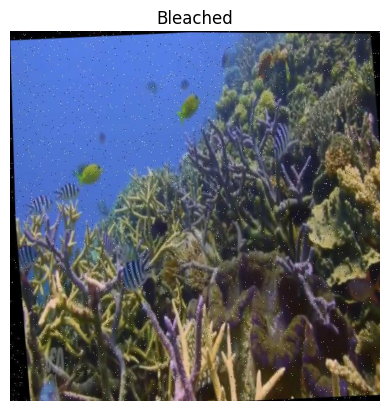

In [35]:
img = view_random_image(target_dir=f"{base_dir}/valid/",target_class="Bleached")

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  5,   5,   5],
        [  0,   0,   0],
        [  3,   3,   3]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  7,   7,   7],
        [  6,   6,   6],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  6,   6,   6],
        [251, 251, 251]],

       ...,

       [[ 13,  13,  13],
        [  8,   8,   8],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  4,   4,   4],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[ 30,  30,  30],
        [  0,   0,   0],
        [ 11,  11,  11],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]], dtype=uint8)
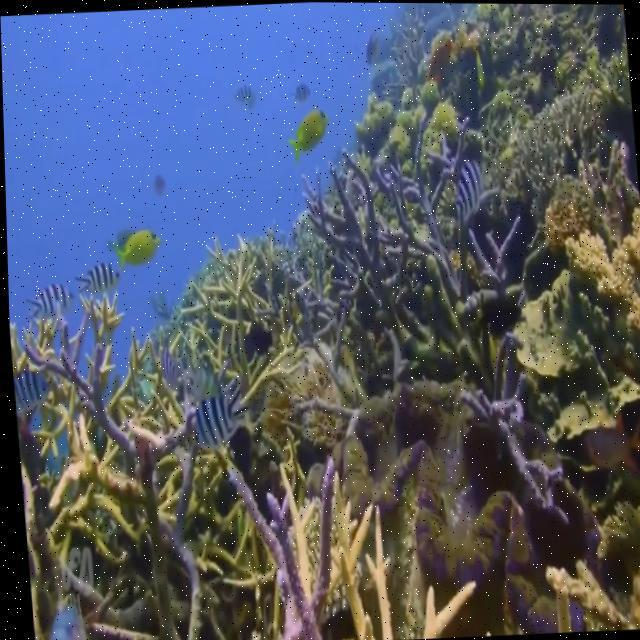

In [36]:
img

# Preprocess the data

In [37]:
# Preprocess data (get all of the pixel values between 1 and 0, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup the train and test directories
train_dir = f"{base_dir}/train/"
test_dir = f"{base_dir}/valid/"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32, # number of images to process at a time
                                               target_size=(224, 224), # convert all images to be 224 x 224
                                               class_mode="binary", # type of problem we're working on
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)


Found 8100 images belonging to 2 classes.
Found 2025 images belonging to 2 classes.


In [38]:
# Define training and test directory paths
train_dir = f"{base_dir}/train/"
test_dir = f"{base_dir}/valid/"

In [39]:
# Create train and test data generators and rescale the data
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

In [40]:
# Turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224, 224),
                                               class_mode='binary',
                                               batch_size=32)

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224, 224),
                                             class_mode='binary',
                                             batch_size=32)

Found 8100 images belonging to 2 classes.
Found 2025 images belonging to 2 classes.


In [41]:
# Get a sample of the training data batch
images, labels = next(train_data)
len(images), len(labels)

(32, 32)

In [42]:
# Create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=20, # rotate the image slightly between 0 and 20 degrees (note: this is an int not a float)
                                             shear_range=0.2, # shear the image
                                             zoom_range=0.2, # zoom into the image
                                             width_shift_range=0.2, # shift the image width ways
                                             height_shift_range=0.2, # shift the image height ways
                                             horizontal_flip=True) # flip the image on the horizontal axis

# Create ImageDataGenerator training instance without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.)

# Create ImageDataGenerator test instance without data augmentation
test_datagen = ImageDataGenerator(rescale=1/255.)

In [43]:
# Import data and augment it from training directory
print("Augmented training images:")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224, 224),
                                                                   batch_size=32,
                                                                   class_mode='binary',
                                                                   shuffle=False) # Don't shuffle for demonstration purposes, usually a good thing to shuffle

# Create non-augmented data batches
print("Non-augmented training images:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='binary',
                                               shuffle=False) # Don't shuffle for demonstration purposes

print("Unchanged test images:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224, 224),
                                             batch_size=32,
                                             class_mode='binary')

Augmented training images:
Found 8100 images belonging to 2 classes.
Non-augmented training images:
Found 8100 images belonging to 2 classes.
Unchanged test images:
Found 2025 images belonging to 2 classes.


In [44]:
# Get data batch samples
images, labels = next(train_data)
augmented_images, augmented_labels = next(train_data_augmented) # Note: labels aren't augmented, they stay the same

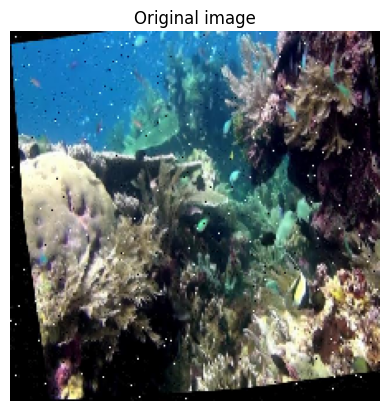

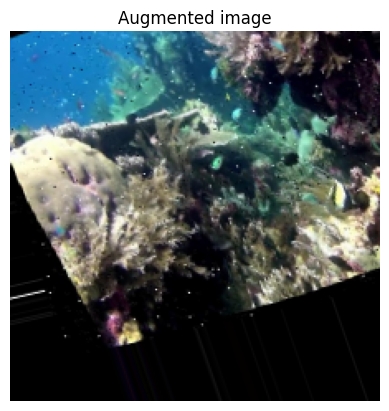

In [45]:
# Show original image and augmented image
random_number = random.randint(0, 31) # we're making batches of size 32, so we'll get a random instance
plt.imshow(images[random_number])
plt.title(f"Original image")
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title(f"Augmented image")
plt.axis(False);

In [46]:
# Import data and augment it from directories
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(train_dir,
                                                                            target_size=(224, 224),
                                                                            batch_size=32,
                                                                            class_mode='binary',
                                                                            shuffle=True) # Shuffle data (default)

Found 8100 images belonging to 2 classes.


# Create model

In [47]:
# Create a CNN model (same as Tiny VGG but for binary classification - https://poloclub.github.io/cnn-explainer/ )
tf.random.set_seed(42)

model = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)), # same input shape as our images
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  #Dropout(0.5),
  Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
# Fit the model
history = model.fit(train_data_augmented_shuffled,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
254/254 ━━━━━━━━━━━━━━━━━━━━ 136s 512ms/step - accuracy: 0.7614 - loss: 0.4660 - val_accuracy: 0.8316 - val_loss: 0.3749
Epoch 2/5
254/254 ━━━━━━━━━━━━━━━━━━━━ 124s 489ms/step - accuracy: 0.8769 - loss: 0.2946 - val_accuracy: 0.8899 - val_loss: 0.2688
Epoch 3/5
254/254 ━━━━━━━━━━━━━━━━━━━━ 122s 480ms/step - accuracy: 0.9007 - loss: 0.2606 - val_accuracy: 0.9111 - val_loss: 0.2324
Epoch 4/5
254/254 ━━━━━━━━━━━━━━━━━━━━ 123s 485ms/step - accuracy: 0.8935 - loss: 0.2710 - val_accuracy: 0.9111 - val_loss: 0.2908
Epoch 5/5
254/254 ━━━━━━━━━━━━━━━━━━━━ 124s 486ms/step - accuracy: 0.8969 - loss: 0.2648 - val_accuracy: 0.9225 - val_loss: 0.2070


In [74]:
model.evaluate(test_data)

64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.9229 - loss: 0.1996


[0.20703667402267456, 0.9224691390991211]

In [75]:
# Check model_8 architecture (same as model_1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

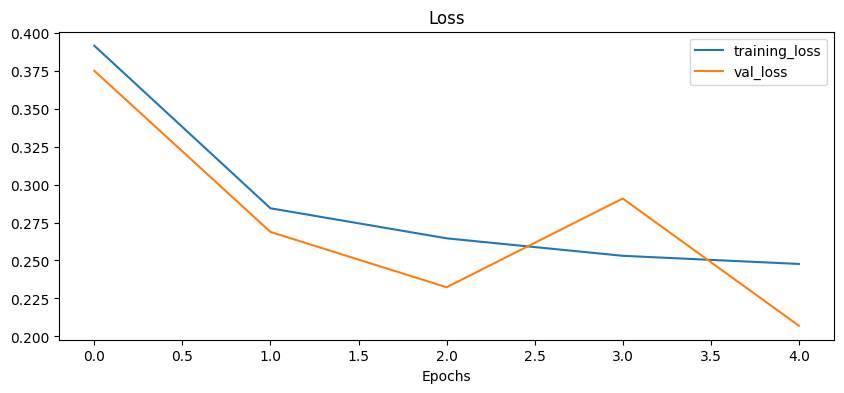

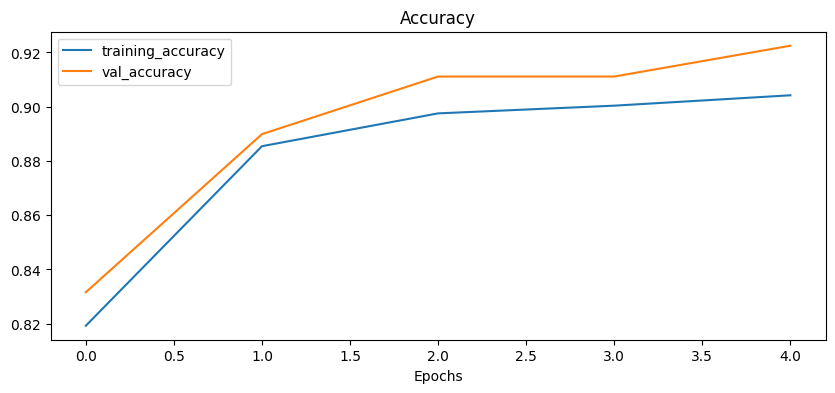

In [76]:
# Check out the TinyVGG model performance
plot_loss_curves(history)

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

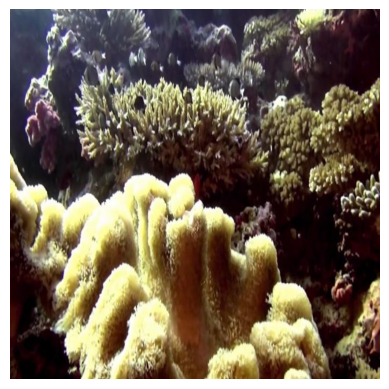

In [77]:
# View our example image
bleached = mpimg.imread(f"{test_dir_Bleached}/youtube-124_jpg.rf.d36e50390cc73d504a15cc05fd6fbfb5.jpg")
plt.imshow(bleached)
plt.axis(False)

In [78]:
# Check the shape of our image
bleached.shape

(640, 640, 3)

In [79]:
# Load in and preprocess our custom image
bleached = load_and_prep_image(f"{test_dir_Bleached}/youtube-116_jpg.rf.715e07964a11be5b622450b3533fded0.jpg")
bleached

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.89075637, 0.7501001 , 0.60866344],
        [0.7948179 , 0.6892757 , 0.55968386],
        [0.5542417 , 0.477471  , 0.3532013 ],
        ...,
        [0.01820715, 0.6142856 , 0.7985993 ],
        [0.0148459 , 0.61092436, 0.7952381 ],
        [0.01148442, 0.60756284, 0.79187655]],

       [[0.9042217 , 0.7552021 , 0.61380553],
        [0.8357743 , 0.7070228 , 0.5820928 ],
        [0.7028811 , 0.60372144, 0.48663464],
        ...,
        [0.01820715, 0.6142856 , 0.7985993 ],
        [0.0148459 , 0.61092436, 0.7952381 ],
        [0.01148442, 0.60756284, 0.79187655]],

       [[0.8584033 , 0.7164065 , 0.5689676 ],
        [0.7894758 , 0.65138054, 0.5231293 ],
        [0.7796719 , 0.64813924, 0.5356342 ],
        ...,
        [0.01820715, 0.6142856 , 0.7985993 ],
        [0.0148459 , 0.61092436, 0.7952381 ],
        [0.01148442, 0.60756284, 0.79187655]],

       ...,

       [[0.7969986 , 0.54603785, 0.09559809],
        [0.87

In [80]:
# Add an extra axis
print(f"Shape before new dimension: {bleached.shape}")
bleached = tf.expand_dims(bleached, axis=0) # add an extra dimension at axis 0
#bleached = bleached[tf.newaxis, ...] # alternative to the above, '...' is short for 'every other dimension'
print(f"Shape after new dimension: {bleached.shape}")
bleached

Shape before new dimension: (224, 224, 3)
Shape after new dimension: (1, 224, 224, 3)


<tf.Tensor: shape=(1, 224, 224, 3), dtype=float32, numpy=
array([[[[0.89075637, 0.7501001 , 0.60866344],
         [0.7948179 , 0.6892757 , 0.55968386],
         [0.5542417 , 0.477471  , 0.3532013 ],
         ...,
         [0.01820715, 0.6142856 , 0.7985993 ],
         [0.0148459 , 0.61092436, 0.7952381 ],
         [0.01148442, 0.60756284, 0.79187655]],

        [[0.9042217 , 0.7552021 , 0.61380553],
         [0.8357743 , 0.7070228 , 0.5820928 ],
         [0.7028811 , 0.60372144, 0.48663464],
         ...,
         [0.01820715, 0.6142856 , 0.7985993 ],
         [0.0148459 , 0.61092436, 0.7952381 ],
         [0.01148442, 0.60756284, 0.79187655]],

        [[0.8584033 , 0.7164065 , 0.5689676 ],
         [0.7894758 , 0.65138054, 0.5231293 ],
         [0.7796719 , 0.64813924, 0.5356342 ],
         ...,
         [0.01820715, 0.6142856 , 0.7985993 ],
         [0.0148459 , 0.61092436, 0.7952381 ],
         [0.01148442, 0.60756284, 0.79187655]],

        ...,

        [[0.7969986 , 0.54603785, 

In [81]:
# Make a prediction on custom image tensor
pred = model.predict(bleached)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[0.5097509]], dtype=float32)

In [82]:
# We can index the predicted class by rounding the prediction probability
pred_class = class_names[int(tf.round(pred)[0][0])]
pred_class

np.str_('Healthy')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
selected class: Bleached
selected picture: /kaggle/working/dataset_split/valid/Bleached/youtube-327_jpg.rf.c716ed6d77ba9e010edf52722e53f0f8.jpg
Predicted Class: 0
Confidence: 97.46%


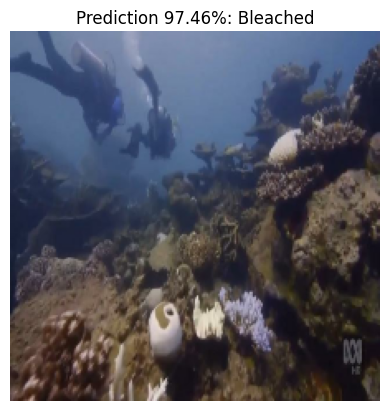

In [83]:
# Test our model on a custom image
pred_and_plot(model, test_dir, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
selected class: Bleached
selected picture: /kaggle/working/dataset_split/valid/Bleached/youtube-900_jpg.rf.bd54db022cfe6d3c1131d692023accd9.jpg
Predicted Class: 0
Confidence: 79.14%


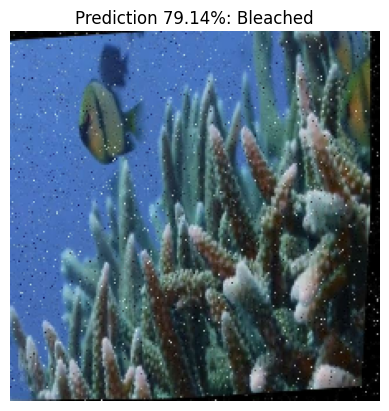

In [84]:
pred_and_plot(model, test_dir, class_names)

## 📖 PROJECT REFLECTION
1. **Data Acquisition:** The dataset utilized for this project is Coral Reefs Images hosted on [Kaggle](https://www.kaggle.com/datasets/asfarhossainsitab/coral-reefs-images). To ensure a reproducible workflow, I implemented kagglehub to automate the download process directly within the notebook.

2. **Technical Challenges:** The primary challenge was resolving high volatility in the training metrics, where validation accuracy fluctuated wildly between epochs (e.g., dropping from 94% to 88%). I diagnosed this as a sampling error caused by the dataset's default structure, which provided a validation set of only ~ 5% (460 images) versus a training set of ~ 9,600. Because the Kaggle input directory is read-only, I could not simply move files to fix this ratio. To resolve it, I engineered a custom Python script using shutil and glob to copy the dataset into the writable working directory, enforce a randomized 80/20 split, and create a statistically significant validation set (~1,900 images). This stabilized the loss curve and ensured the final accuracy metrics were reliable.

3. **Theoretical Foundation:** I referenced the Convolutional Neural Network documentation to gain a comprehensive understanding of the underlying mathematical operations and feature extraction processes utilized by CNNs.

4. **Implementation References:** The core architecture was influenced by the notebook "[03_convolutional_neural_networks_in_tensorflow](https://colab.research.google.com/github/mrdbourke/tensorflow-deep-learning/blob/main/03_convolutional_neural_networks_in_tensorflow.ipynb)". This reference was instrumental in troubleshooting syntax errors and implementing best practices for model optimization.

5. **Testing & Evaluation:** The model was evaluated using a held-out validation set. The final iteration achieved a validation accuracy of <b>92.24%</b> and a loss of <b>0.2070</b>, demonstrating the model's ability to correctly classify the coral reef images without significant overfitting.